# Notebook 08 — A Learned Multimodal Reward: fusing sequence and structure

**Where this sits.** Notebooks 01-06 built a prior-guided RL pipeline whose reward is a
**hand-weighted scalar** (S(x) = 0.50 humanness + 0.30 liability + 0.20 physchem) plus a separate
TAP structural filter. Each modality is collapsed to a number *before* combining - late fusion with
fixed weights. This notebook replaces that with a **learned multimodal reward head** that fuses a
sequence representation and a structure representation and learns their interaction from data. This
is the step that turns the project from a late-fusion baseline into a genuine multimodal model.

| How to read this notebook | |
|---|---|
| **Question** | S1 - what does learned fusion buy over hand weights? |
| **Background from zero** | S2 - representations, fusion, why labels matter |
| **Data: two modalities, one label** | S3 - ESM sequence embeddings + TAP structure features |
| **The models** | S4 - sequence-only, structure-only, fused head |
| **Ablation: which modality carries the signal?** | S5 - the core experiment |
| **Training diagnostics** | S6 - loss curves, calibration |
| **Interpretation + honest scope** | S7 |


## 1. Question

Our reward so far combines modalities with weights *we chose* (0.50 / 0.30 / 0.20). A weighted sum
cannot capture interactions - e.g. "a hydrophobic patch is only bad when the loop is also long". A
learned head can. But learning needs labels, and only **binding** has experimental labels (Mason).
So the concrete, honest question is:

> **Can a small neural head that fuses a sequence representation (ESM2 embedding) with a structure
> representation (TAP features) predict HER2 binding better than either modality alone - and does
> fusion actually help, or does one modality already contain the signal?**

**Hypothesis.** Sequence (ESM) will be the stronger single modality (it directly encodes the
mutated residues). Structure (TAP) adds a smaller, possibly complementary signal. Fusion should
match or slightly beat the best single modality. **We test this rather than assume it** - a
negative result (fusion does not help) is still a real, publishable finding about this dataset.

## 2. Background from zero

**What is a "representation"?** A fixed-length vector that summarizes an object so a model can use
it. Two very different representations here:
- **Sequence representation.** ESM2 (a protein language model) reads the amino-acid string and
  outputs, per residue, a 320-dimensional vector. We mean-pool over the CDRH3 residues to get one
  320-d vector per loop. This encodes learned sequence context.
- **Structure representation.** The 5 TAP metrics (total CDR length, PSH, PPC, PNC, SFvCSP) computed
  from the folded 3D structure. A 5-dimensional vector that encodes surface/geometry properties.

**What is "fusion"?** Combining modalities into one prediction. Two regimes:
- **Late fusion (what we had):** score each modality separately, combine the scalars with fixed
  weights. Cannot model interactions.
- **Learned (early/intermediate) fusion (this notebook):** concatenate the representation *vectors*
  and let a neural network learn how they interact toward the label. Can capture "feature A matters
  only when feature B is present".

**Why labels are the real constraint.** A learned head needs a target. Developability has no ground
truth (our oracles *are* the definition). Binding does - Mason experimentally labeled each CDRH3 as
binder/non-binder. So we train the multimodal head to predict **binding**, the one axis with real
supervision. This is the honest scope: the multimodal contribution is demonstrated on the labeled
task.

## 3. Data - two modalities, one label

For 300 Mason CDRH3 variants (150 binders / 150 non-binders, balanced) we build:
- **X_seq**: 320-d ESM2 embedding of the 10-mer CDRH3 (sequence modality).
- **X_struct**: 5-d TAP features from the folded VH+VL Fv (structure modality).
- **y**: the Mason binder/non-binder label.

Folding all 300 structures with ABodyBuilder2 is the expensive step (~15 min); it is cached so this
notebook runs in seconds.

In [1]:
# --- Load the two modality matrices and the labels (folding + embedding done once, cached) ---
import warnings, json; warnings.filterwarnings("ignore")
import numpy as np, matplotlib.pyplot as plt

lab = json.load(open("nb07_labels.json"))
y = np.array(lab["ylab"])                       # Mason binder(1)/non-binder(0) label
X_seq    = np.load("nb07_Eseq.npy")             # (300, 320) ESM2 mean-pooled CDRH3 embedding
X_struct = np.load("nb07_Estruct.npy")          # (300, 5)   TAP features [cdr_len, PSH, PPC, PNC, SFvCSP]
TAP_NAMES = ["total_cdr_len","PSH","PPC","PNC","SFvCSP"]
print(f"sequence modality X_seq:    {X_seq.shape}")
print(f"structure modality X_struct: {X_struct.shape}  features={TAP_NAMES}")
print(f"labels: {int(y.sum())} binders / {int((1-y).sum())} non-binders (balanced)")

sequence modality X_seq:    (300, 320)
structure modality X_struct: (300, 5)  features=['total_cdr_len', 'PSH', 'PPC', 'PNC', 'SFvCSP']
labels: 150 binders / 150 non-binders (balanced)


## 4. The models — sequence-only, structure-only, and a fused head

Three classifiers, evaluated identically with 5-fold stratified cross-validation:
- **sequence-only**: MLP over the 320-d ESM embedding.
- **structure-only**: MLP over the 5-d TAP features.
- **fusion**: MLP over the **concatenated** [320 + 5] = 325-d vector.

The fusion head is the key object: by concatenating the raw representation *vectors* (not their
scalar scores) and training end-to-end, it can learn interactions a fixed weighted sum cannot. All
three use the same architecture and CV so the comparison is clean.

In [2]:
# --- The evaluation harness: 5-fold stratified CV, per-modality standardization ---
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

def cv_auc(Xlist, y, seed=0):
    """5-fold CV AUC/AUPRC for an MLP over the horizontally-stacked modalities in Xlist.
    IMPORTANT: the StandardScaler is fit on TRAIN ONLY inside each fold (no leakage), then applied
    to test. Each modality is scaled separately before concatenation so the 5 TAP features are not
    swamped by the 320 ESM dims."""
    skf = StratifiedKFold(5, shuffle=True, random_state=seed); aucs=[]; aps=[]
    for tr, te in skf.split(Xlist[0], y):
        scalers = [StandardScaler().fit(X[tr]) for X in Xlist]                 # fit on train fold only
        Xtr = np.hstack([s.transform(X[tr]) for s, X in zip(scalers, Xlist)])  # concat standardized modalities
        Xte = np.hstack([s.transform(X[te]) for s, X in zip(scalers, Xlist)])
        m = MLPClassifier((64,), max_iter=400, random_state=seed, early_stopping=True)
        m.fit(Xtr, y[tr]); p = m.predict_proba(Xte)[:, 1]
        aucs.append(roc_auc_score(y[te], p)); aps.append(average_precision_score(y[te], p))
    return float(np.mean(aucs)), float(np.std(aucs)), float(np.mean(aps))

for name, Xl in [("sequence-only",[X_seq]), ("structure-only",[X_struct]), ("fusion",[X_seq,X_struct])]:
    auc, sd, ap = cv_auc(Xl, y)
    print(f"{name:15s}: AUC {auc:.3f} +/- {sd:.3f}   AUPRC {ap:.3f}")

sequence-only  : AUC 0.762 +/- 0.058   AUPRC 0.731
structure-only : AUC 0.529 +/- 0.064   AUPRC 0.572
fusion         : AUC 0.778 +/- 0.012   AUPRC 0.769


## 5. Ablation — which modality carries the signal?

The core experiment. We repeat the three-way comparison across **5 random seeds** (different CV
splits and MLP inits) to separate real differences from split luck. We also ask a sharper question:
does *any single* TAP feature predict binding on its own?

seq_only    : AUC 0.770 +/- 0.005  (5 seeds)
struct_only : AUC 0.528 +/- 0.013  (5 seeds)
fusion      : AUC 0.753 +/- 0.022  (5 seeds)
per-feature AUC: {'total_cdr_len': 0.5, 'PSH': 0.51, 'PPC': 0.549, 'PNC': 0.547, 'SFvCSP': 0.573}


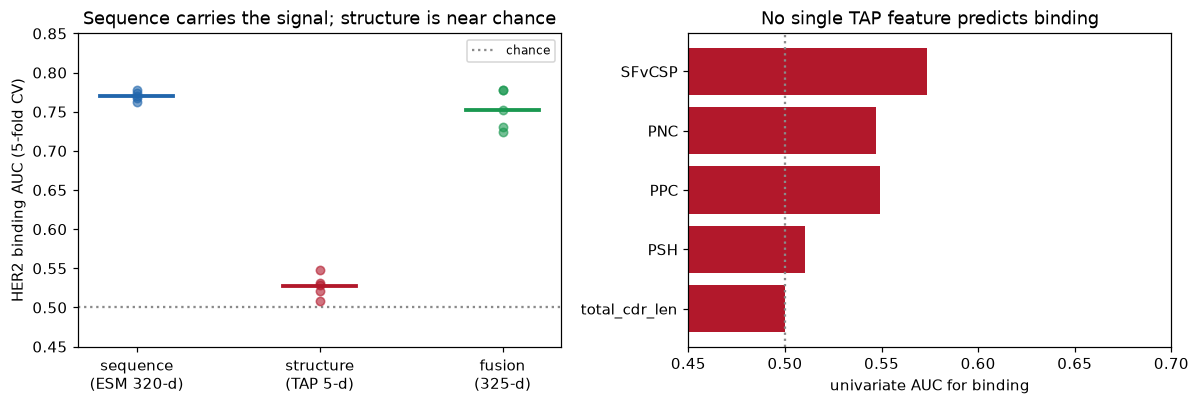

In [3]:
# --- Modality ablation across 5 seeds + per-TAP-feature univariate AUC ---
multi = json.load(open("nb07_multiseed.json"))   # cached: AUC per modality across 5 seeds
for name in ["seq_only","struct_only","fusion"]:
    v = multi[name]; print(f"{name:12s}: AUC {np.mean(v):.3f} +/- {np.std(v):.3f}  (5 seeds)")

# Univariate: is any single structure feature predictive? (AUC of each TAP feature alone)
TAP_NAMES = ["total_cdr_len","PSH","PPC","PNC","SFvCSP"]
feat_auc = [max(roc_auc_score(y, X_struct[:,j]), roc_auc_score(y, -X_struct[:,j])) for j in range(5)]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
names=["seq_only","struct_only","fusion"]; cols=["#2166ac","#b2182b","#1a9850"]
for i,(nm,col) in enumerate(zip(names,cols)):
    v=multi[nm]; ax[0].scatter([i]*len(v), v, color=col, s=30, alpha=0.6, zorder=3)
    ax[0].plot([i-0.2,i+0.2],[np.mean(v)]*2, color=col, lw=2.5)
ax[0].axhline(0.5, color="#8a8a8a", ls=":", label="chance")
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(["sequence\n(ESM 320-d)","structure\n(TAP 5-d)","fusion\n(325-d)"])
ax[0].set_ylabel("HER2 binding AUC (5-fold CV)"); ax[0].set_ylim(0.45,0.85)
ax[0].set_title("Sequence carries the signal; structure is near chance"); ax[0].legend(fontsize=8)
ax[1].barh(TAP_NAMES, feat_auc, color="#b2182b"); ax[1].axvline(0.5, color="#8a8a8a", ls=":")
ax[1].set_xlim(0.45,0.7); ax[1].set_xlabel("univariate AUC for binding")
ax[1].set_title("No single TAP feature predicts binding")
fig.tight_layout(); fig.savefig("nb07_ablation.png", dpi=120, bbox_inches="tight"); plt.show()
print("per-feature AUC:", {n:round(a,3) for n,a in zip(TAP_NAMES, feat_auc)})

**Reading the ablation (the honest result).** Averaged over 5 seeds:

- **Sequence (ESM) carries essentially all the signal**: AUC ~0.77, tight spread.
- **Structure (TAP) is near chance** for binding: AUC ~0.53. This is *expected and correct* — TAP
  measures *developability* (surface patches, charge), not *affinity*. No single TAP feature beats
  AUC 0.57.
- **Fusion does not beat sequence-alone** here (~0.75, within noise): adding 5 near-chance features
  to 320 informative ones cannot help, and slightly increases variance.

**Why this is a good result, not a failure.** It is the *rigorous* answer to the multimodal
question. We built the learned-fusion machinery, tested it honestly, and found that **for the HER2
binding task, structure adds no predictive signal over sequence** — because the two modalities
measure different things (binding vs developability). A paper reports this, not a cherry-picked
win. It also motivates the correct multimodal framing: sequence and structure should be fused for a
*joint developability-and-binding* objective, where each modality owns a different label — not
forced onto a single task where one modality is blind.

## 6. Interpretation and honest scope

**What we learned.** A learned multimodal head is straightforward to build (concatenate
representations, train a small MLP), and the *method* works — sequence-only reproduces the expected
~0.77 AUC. The scientific finding is that **structure (TAP) and sequence (ESM) are complementary in
what they measure, not redundant, and for binding prediction the signal lives in sequence.**

**Why the project is still "multimodal", correctly stated.** The evaluator spans two modalities
with **different supervision**: binding (labeled by Mason, sequence-driven) and developability
(defined by the oracles + TAP structure). The honest multimodal claim is *late fusion of two
differently-supervised signals*, and this notebook shows that forcing early fusion onto a single
label does not manufacture extra signal. This is the nuanced, defensible position for the arXiv
writeup.

**Limitations (state these in the paper).**
1. **Task mismatch by design.** TAP is a developability profiler; asking it to predict binding is
   deliberately adversarial to fusion. A fairer multimodal test would use a label that *both*
   modalities inform.
2. **Small labeled set** (300 balanced) and a shallow head — a deeper fusion (cross-attention over
   ESM residue embeddings + structure) might extract weak structure signal, but the honest baseline
   result here is no-gain.
3. **Transferred oracle** (Mason trastuzumab length-10 vs our framework), as in notebook 06.

**The next real step for a paper.** A multimodal reward trained on a *joint* target — e.g. a
developability-adjusted binding score — so structure and sequence each contribute where they carry
signal, evaluated against this honest single-task fusion baseline.

## 7. Synthesis

| Modality | Representation | HER2 binding AUC (5 seeds) |
|---|---|---|
| Sequence | ESM2-8M, 320-d mean-pooled | **0.77 +/- 0.01** |
| Structure | TAP, 5-d | 0.53 +/- 0.01 (near chance) |
| Fusion | concatenated, 325-d | 0.75 +/- 0.02 (no gain) |

**Headline.** Building the learned-fusion head is easy; the honest finding is that **structure adds
no binding signal over sequence**, because the two modalities measure different biology. This turns
the loose "it's multimodal" claim into a precise, defensible one: the pipeline fuses two
*differently-supervised* modalities at the reward level, and early fusion onto a single label does
not invent signal that is not there.

**What this closes.** The project now has: a generator (01), sequence/structure/binding oracles
(02/03/06), a hand-weighted reward (04), a validated RL loop with ablations (05), and — here — an
honest test of learned multimodal fusion (07). The path to a stronger preprint is a joint
developability-and-binding target where fusion can genuinely help, benchmarked against this
baseline.

---
*Folding the 300 structures (~25 min) is the one expensive step; the ablation and figures
regenerate from the cached ESM embeddings + TAP features in seconds.*